In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from adjustText import adjust_text

In [3]:
raw_expressions = pd.read_csv('raw_counts_ici_samples.tsv', sep='\t', index_col=0)

raw_expressions

,LuC-136_S6_ME_L001_R1_001ReadsPerGene,LuC-128_S14_ME_L001_R1_001ReadsPerGene,LuC-95_S5_ME_L001_R1_001ReadsPerGene,LuC-135_S12_ME_L001_R1_001ReadsPerGene,LuC2_S6_L007_R1_001ReadsPerGene,LuC-84_S5_ME_L001_R1_001ReadsPerGene,Luc_65_S30_R1_001ReadsPerGene,LuC_59_S1_R1_001ReadsPerGene,LuC-98_S11_ME_L001_R1_001ReadsPerGene,LuC-80c_S10_ME_L001_R1_001ReadsPerGene,...,LuC-91_S1_ME_L001_R1_001ReadsPerGene,Luc_66_S24_R1_001ReadsPerGene,Luc_63_S22_R1_001ReadsPerGene,LuC-123_S13_ME_L001_R1_001ReadsPerGene,LuC-43_S12_R1_001ReadsPerGene,LuC-17_S8_R1_001ReadsPerGene,LuC_54_S12_R1_001ReadsPerGene,LuC_27_S10_R1_001ReadsPerGene,LuC-85_CGRNAReadsPerGene,LuC-111_S3_ME_L001_R1_001ReadsPerGene
ENSG00000223972,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000227232,0,0,0,0,0,4,0,0,0,0,...,1,0,0,2,0,0,0,0,78,0
ENSG00000278267,1,0,0,3,0,3,0,0,1,0,...,0,0,0,0,0,0,0,0,8,2
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
ENSG00000284332,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,78,101,45,92,30,116,0,0,19,4,...,21,27,18,174,16,69,52,42,229,72
ENSG00000275405,2,15,2,0,0,2,0,0,0,0,...,1,0,0,3,0,0,0,5,14,2
ENSG00000275987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
ENSG00000277475,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2,0


In [4]:
raw_expressions.rename(columns = {'R1-1': 'HCT-15-4', 
                                     'R1-2': 'HCT-15-5',
                                     'R1-3': 'HCT-15-6',
                                     'HCT_WT1': 'HCT-15-1',
                                     'HCT_WT2': 'HCT-15-2',
                                     'HCT_WT3': 'HCT-15-3',
                                    }, inplace = True)

In [ ]:
mean_gene_lenghts = pd.read_csv('gene_length.tsv', sep = '\t', index_col=0)['median_trna_lenght']
mean_gene_lenghts

KeyError: 'median_trna_lenght'

In [6]:
dataset_normalized = raw_expressions.copy()

for gene in dataset_normalized.index:
    dataset_normalized.loc[gene] = dataset_normalized.loc[gene]/mean_gene_lenghts[gene]*10**3
    
dataset_normalized = dataset_normalized.apply(lambda x: x/x.sum()*10**6)

dataset_normalized

/tmp/ipykernel_7901/1499405756.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8771929824561404' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset_normalized.loc[gene] = dataset_normalized.loc[gene]/mean_gene_lenghts[gene]*10**3
/tmp/ipykernel_7901/1499405756.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.985074626865672' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset_normalized.loc[gene] = dataset_normalized.loc[gene]/mean_gene_lenghts[gene]*10**3
/tmp/ipykernel_7901/1499405756.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.746268656716418' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

,LuC-136_S6_ME_L001_R1_001ReadsPerGene,LuC-128_S14_ME_L001_R1_001ReadsPerGene,LuC-95_S5_ME_L001_R1_001ReadsPerGene,LuC-135_S12_ME_L001_R1_001ReadsPerGene,LuC2_S6_L007_R1_001ReadsPerGene,LuC-84_S5_ME_L001_R1_001ReadsPerGene,Luc_65_S30_R1_001ReadsPerGene,LuC_59_S1_R1_001ReadsPerGene,LuC-98_S11_ME_L001_R1_001ReadsPerGene,LuC-80c_S10_ME_L001_R1_001ReadsPerGene,...,LuC-91_S1_ME_L001_R1_001ReadsPerGene,Luc_66_S24_R1_001ReadsPerGene,Luc_63_S22_R1_001ReadsPerGene,LuC-123_S13_ME_L001_R1_001ReadsPerGene,LuC-43_S12_R1_001ReadsPerGene,LuC-17_S8_R1_001ReadsPerGene,LuC_54_S12_R1_001ReadsPerGene,LuC_27_S10_R1_001ReadsPerGene,LuC-85_CGRNAReadsPerGene,LuC-111_S3_ME_L001_R1_001ReadsPerGene
ENSG00000223972,0.000000,0.000000,0.000000,0.000000,0.092012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
ENSG00000227232,0.000000,0.000000,0.000000,0.000000,0.000000,0.187982,0.0,0.0,0.000000,0.000000,...,0.056725,0.000000,0.000000,0.126619,0.000000,0.000000,0.00000,0.000000,2.192455,0.000000
ENSG00000278267,1.780016,0.000000,0.000000,7.979186,0.000000,2.819730,0.0,0.0,2.220523,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,4.497344,1.993452
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.122402,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
ENSG00000284332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,3.720945,3.684658,2.996449,6.557827,1.258724,2.921992,0.0,0.0,1.130691,1.211289,...,0.638498,1.251387,1.142218,5.904492,0.521382,2.184037,1.95084,1.255719,3.450137,1.923283
ENSG00000275405,1.463326,8.393044,2.042569,0.000000,0.000000,0.772687,0.0,0.0,0.000000,0.000000,...,0.466329,0.000000,0.000000,1.561374,0.000000,0.000000,0.00000,2.292798,3.235053,0.819394
ENSG00000275987,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.263393,0.000000
ENSG00000277475,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.095339,0.00000,0.000000,0.090760,0.000000


/tmp/ipykernel_7901/509991403.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pca_res = pca.fit_transform(dataset_normalized.applymap(lambda x: np.log10(x+1)).T).T


Text(0.5, 1.0, 'PCA of log(TPM) expression values')

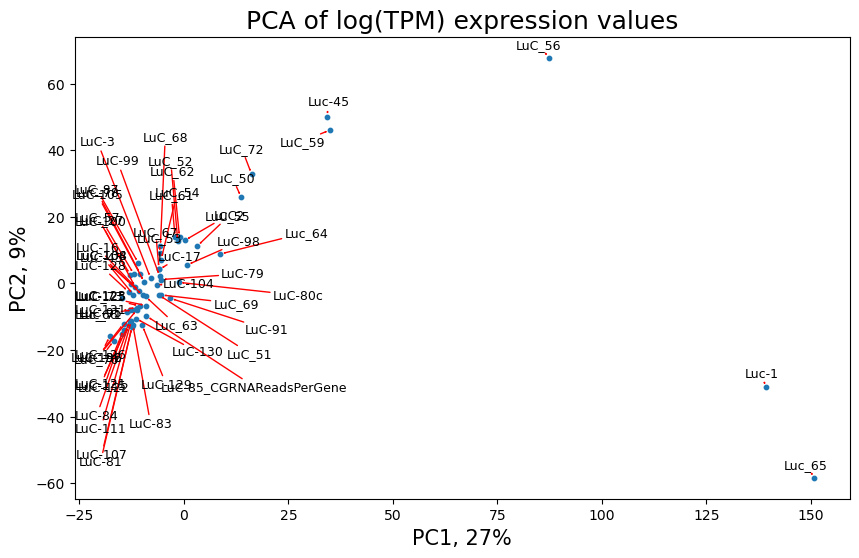

In [7]:
plt.figure(figsize=(10, 6))

pca = PCA(n_components=2)
pca_res = pca.fit_transform(dataset_normalized.applymap(lambda x: np.log10(x+1)).T).T
plt.scatter(pca_res[0], pca_res[1], s = 10)

expl_var = pca.explained_variance_ratio_

# Add labels and legend
plt.xlabel(f'PC1, {round(expl_var[0]*100)}%', fontsize=15)
plt.ylabel(f'PC2, {round(expl_var[1]*100)}%', fontsize=15)

annotations = []

for i, label in enumerate(dataset_normalized.columns):
    annotations.append(plt.text(pca_res[0][i], pca_res[1][i], label.split('_S')[0], fontsize=9, ha='right'))

adjust_text(annotations, expand=(1.2, 2), arrowprops=dict(arrowstyle='->', color='red'))

plt.title('PCA of log(TPM) expression values', fontsize=18)

In [8]:
data_log = dataset_normalized.applymap(lambda x: np.log10(x + 1))

top_genes = data_log.var(axis=1).sort_values(ascending=False).head(2000).index
data_top = data_log.loc[top_genes]

data_samples = data_top.T
corr = data_samples.corr(method="pearson")


/tmp/ipykernel_7901/4244250328.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_log = dataset_normalized.applymap(lambda x: np.log10(x + 1))


/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/khokholmongolll/miniconda3/envs/ml/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


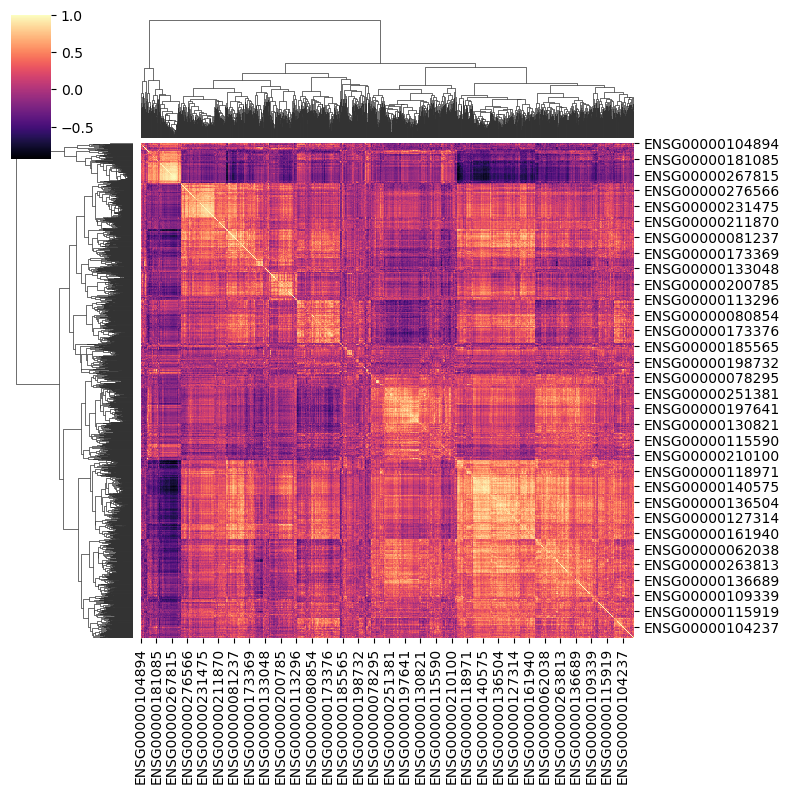

In [9]:
sns.clustermap(
    corr,
    figsize=(8, 8),
    cmap="magma",
    metric="euclidean",
    method="average"
)